In [1]:
import gurobipy as gp
from gurobipy import GRB


In [48]:
# Facility locations: name -> (x, y)
facility_locations = {
    'A': (1, 5), 
    'B': (3.1, 7), 
    'C': (5.8, 6), 
    'D': (2.7, 1), 
    'E': (6, 1)
}

# Demand locations: name -> (x, y)
demand_locations = {
    '1': (1, 7), 
    '2': (2.7, 5.5), 
    '3': (5.8, 7), 
    '4': (4.5, 4.1), 
    '5': (7, 5), 
    '6': (4.2, 0.5)
}

#connection and distance
connection = {
    'A' : {'1' : 120, '2' : 30, '4' : 250},
    'B' : {'1' : 85, '2' : 60, '3' : 100, '4' : 180},
    'C' : {'3' : 20, '4' : 80, '5' : 95},
    'D' : {'2' : 150, '4' : 160, '6' : 180},
    'E' : {'4' : 140, '5' : 175, '6' : 200}
}

# production
# Resource Price at each facility location
price = {
'A': {'steel': 5.0, 'plastic': 4.0, 'energy': 3.5, 'labour': 6.0},
'B': {'steel': 4.5, 'plastic': 4.2, 'energy': 3.8, 'labour': 6.5},
'C': {'steel': 5.2, 'plastic': 3.8, 'energy': 3.6, 'labour': 5.8},
'D': {'steel': 4.8, 'plastic': 4.5, 'energy': 4.0, 'labour': 6.2},
'E': {'steel': 5.5, 'plastic': 3.9, 'energy': 3.7, 'labour': 6.1}
}

# Resource Requirements
requirements = {
'alpha' : {'steel': 2, 'plastic': 3, 'energy': 5, 'labour': 4},
'beta' : {'steel': 4, 'plastic': 1, 'energy': 2, 'labour': 3},
'gamma' : {'steel': 1, 'plastic': 4, 'energy': 3, 'labour': 2}
}

# Facility production capacity bounds
facility_production_lower = {'A': 200, 'B': 150, 'C': 50, 'D': 250, 'E': 180}
facility_production_upper = {'A': 800, 'B': 1000, 'C': 600, 'D': 1200, 'E': 900}

# selling
# Demand at each location
demand = {
'alpha' : {'1': 205, '2': 475, '3': 600, '4': 900, '5': 350, '6': 80},
'beta' : {'1': 380, '2': 215, '3': 490, '4': 675, '5': 750, '6': 950},
'gamma' : {'1': 590, '2': 800, '3': 270, '4': 450, '5': 100, '6': 410}
}

# Shipping Cost
shipping_cost = {'alpha': 4, 'beta': 3.5, 'gamma': 2}

# product price at each location 
selling_price = {
'alpha' : {'1': 65, '2': 60, '3': 48, '4': 80, '5': 55, '6': 90},
'beta' : {'1': 50, '2': 45, '3': 70, '4': 65, '5': 30, '6': 85},
'gamma' : {'1': 42, '2': 55, '3': 38, '4': 42, '5': 25, '6': 40}
}

In [53]:
m = gp.Model("facility_location")

# Decision variables
open_location = m.addVars(facility_locations.keys(), vtype=GRB.BINARY, name="Open") #open facility(1) or not(0)
product_to_produce = m.addVars(facility_locations.keys(), requirements.keys(),  vtype=GRB.INTEGER, lb=0, name="produce")  #number of product to produce
ship_location_demand = m.addVars([(f, d, p) for f in facility_locations for d in connection[f] for p in requirements],  vtype=GRB.INTEGER, lb=0, name="shipment") #number of product sent

# Production
for f in facility_locations:
    total_produced_at_f = gp.quicksum(product_to_produce[f, p] for p in requirements)
    
    # Production lower bound
    m.addConstr(
        open_location[f] * facility_production_lower[f] <= total_produced_at_f, 
        name=f"min_cap_{f}"
    )

    # Production upper bound
    m.addConstr(
        open_location[f] * facility_production_upper[f] >= total_produced_at_f, 
        name=f"max_cap_{f}"
    )

    # Each product sent cannot exceed product produced
    for p in requirements:
        total_sent_product_fp = gp.quicksum(ship_location_demand[f, d, p] for d in connection[f])
        # Total Product sent 
        m.addConstr(
            total_sent_product_fp <= product_to_produce[f, p], 
            name=f"supply_balance_{f}_{p}"
        )
    

# product sent 
for d in demand_locations :
    #Demands doesnt have to be met.
    for p in requirements:
        met_demand = gp.quicksum(ship_location_demand[f, d, p] for f in facility_locations if (f, d, p) in ship_location_demand)    

        m.addConstr(
            met_demand <= demand[p][d], 
            name=f"demand_{d}_{p}"  
        )

# production and shipping cost
total_production_cost = 0
total_shipping_cost = 0
total_cost = 0
for f in facility_locations:
    price_to_produce = {
        p : gp.quicksum(requirements[p][resource] * price[f][resource] for resource in requirements[p])
        for p in requirements
    }

    #production cost at each facility       
    production_cost_at_f = gp.quicksum(product_to_produce[f, p] * price_to_produce[p] for p in requirements)
    total_production_cost += production_cost_at_f

    #shipping cost at each facility
    shipping_cost_at_f = gp.quicksum(ship_location_demand[f, d, p] * shipping_cost[p] * connection[f][d] for d in demand_locations if d in connection[f] for p in requirements) 
    total_shipping_cost += shipping_cost_at_f

total_cost += (total_production_cost + total_shipping_cost)

# Maximum cost
m.addConstr(
    total_cost <= 500000
)

# Selling
total_revenue = 0
for f in facility_locations:
    
    revenue = gp.quicksum(ship_location_demand[f, d, p] * selling_price[p][d] for d in connection[f] for p in requirements)
    total_revenue += revenue
    
m.setObjective(total_revenue, GRB.MAXIMIZE)


In [54]:
m.optimize()

Gurobi Optimizer version 12.0.3 build v12.0.3rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) Ultra 9 185H, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 22 logical processors, using up to 22 threads

Optimize a model with 44 rows, 68 columns and 214 nonzeros
Model fingerprint: 0x6ffbd850
Variable types: 0 continuous, 68 integer (5 binary)
Coefficient statistics:
  Matrix range     [1e+00, 1e+03]
  Objective range  [3e+01, 9e+01]
  Bounds range     [1e+00, 1e+00]
  RHS range        [8e+01, 5e+05]
Found heuristic solution: objective -0.0000000
Presolve removed 1 rows and 0 columns
Presolve time: 0.00s
Presolved: 43 rows, 68 columns, 212 nonzeros
Variable types: 0 continuous, 68 integer (5 binary)

Root relaxation: objective 1.495077e+05, 52 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objective Bounds      |     Work
 Expl Unexpl |  Obj  Depth IntInf | Incumbent    BestBd   Gap | It/Node Time

     0     0 1495

In [62]:
if m.status == GRB.OPTIMAL:
    print(f"Optimal solution found with total revenue: {m.objVal:.2f}")
    print("\nFacilities opened, their productions, and their shipments:")
    for f in facility_locations :
        if open_location[f].x > 0.5:
            #facility_opened = [f] 
            print(f"\nFacility {f} :")
            for p in requirements:
                #product produced
                print(f"Product : {p}")
                print(f"produced : {product_to_produce[f, p].x}")
                #product sent
                print("Sent to :")
                for d in connection[f] :
                    print(f"{d} : {ship_location_demand[f,d,p].x}")
                
                
                #product_sent = sum(ship_location_demand[f, d, p].x for d in connection[f])
                #print(f"{p} = {product_sent}")
            
            total_product_produced = sum(product_to_produce[f, p].x  for p in requirements)
            print(f"Product produced : {total_product_produced}")
            total_product_sent = sum(ship_location_demand[f, d, p].x for d in connection[f] for p in requirements)
            print(f"Total product sent : {total_product_sent}")

    print(f"\nTotal Cost : {total_cost.getValue()}")

else:
    print("No optimal solution found")

Optimal solution found with total revenue: 149494.00

Facilities opened, their productions, and their shipments:

Facility A :
Product : alpha
produced : 475.0
Sent to :
1 : 0.0
2 : 475.0
4 : 0.0
Product : beta
produced : 215.0
Sent to :
1 : 0.0
2 : 215.0
4 : 0.0
Product : gamma
produced : 110.0
Sent to :
1 : 0.0
2 : 110.0
4 : 0.0
Product produced : 800.0
Total product sent : 800.0

Facility B :
Product : alpha
produced : 0.0
Sent to :
1 : 0.0
2 : 0.0
3 : 0.0
4 : 0.0
Product : beta
produced : 0.0
Sent to :
1 : 0.0
2 : 0.0
3 : 0.0
4 : 0.0
Product : gamma
produced : 1000.0
Sent to :
1 : 310.0
2 : 690.0
3 : -0.0
4 : 0.0
Product produced : 1000.0
Total product sent : 1000.0

Facility C :
Product : alpha
produced : 109.0
Sent to :
3 : -0.0
4 : 109.0
5 : 0.0
Product : beta
produced : 491.0
Sent to :
3 : 490.0
4 : 1.0
5 : 0.0
Product : gamma
produced : -0.0
Sent to :
3 : 0.0
4 : 0.0
5 : 0.0
Product produced : 600.0
Total product sent : 600.0

Facility E :
Product : alpha
produced : 0.0
Sent t

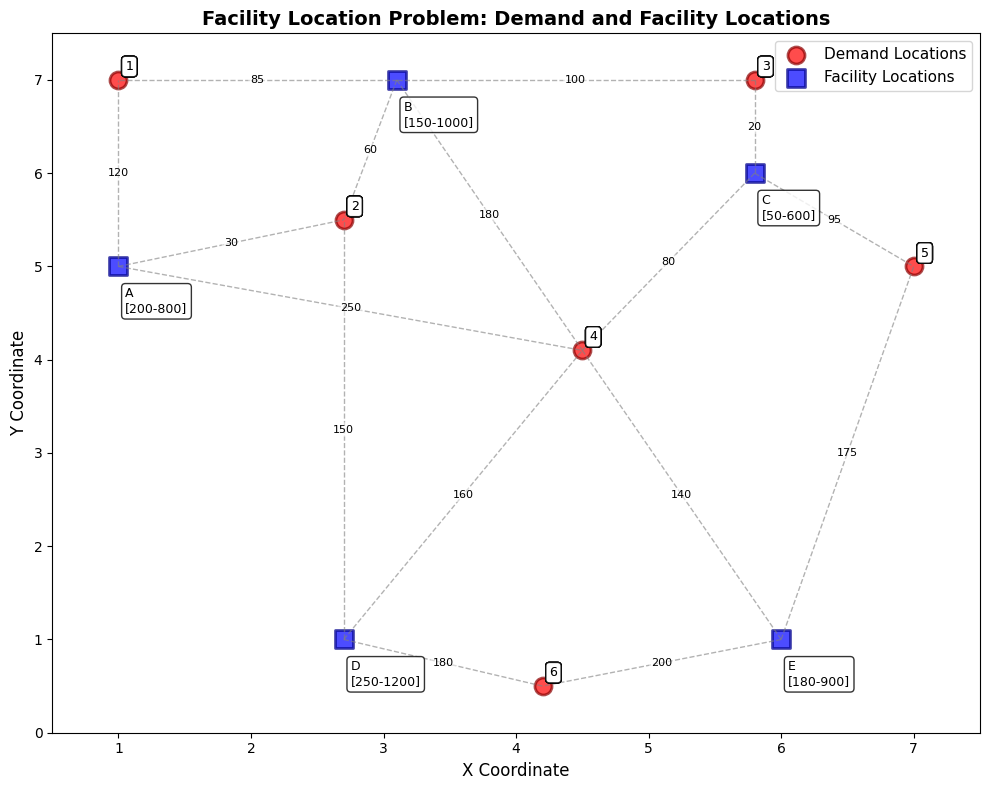

In [64]:
import matplotlib.pyplot as plt

# Create the plot
plt.figure(figsize=(10, 8))

# Plot demand locations with circle markers
demand_x = [loc[0] for loc in demand_locations.values()]
demand_y = [loc[1] for loc in demand_locations.values()]
plt.scatter(demand_x, demand_y, marker='o', s=150, c='red', alpha=0.7, 
           label='Demand Locations', edgecolor='darkred', linewidth=2)

# Plot facility locations with square markers
facility_x = [loc[0] for loc in facility_locations.values()]
facility_y = [loc[1] for loc in facility_locations.values()]
plt.scatter(facility_x, facility_y, marker='s', s=150, c='blue', alpha=0.7, 
           label='Facility Locations', edgecolor='darkblue', linewidth=2)


# Show distance
for f, connections in connection.items():
    fac_loc = facility_locations[f] # Get facility coordinates
    for d, dist in connections.items():
        dem_loc = demand_locations[d] # Get demand location coordinates

        # Plot the line
        plt.plot([fac_loc[0], dem_loc[0]], [fac_loc[1], dem_loc[1]],
                 color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=1) # zorder sends lines to back

        # Calculate midpoint for the label
        mid_x = (fac_loc[0] + dem_loc[0]) / 2
        mid_y = (fac_loc[1] + dem_loc[1]) / 2

        # Add the distance label near the midpoint
        plt.text(mid_x, mid_y, str(dist), fontsize=8, color='black',
                 ha='center', va='center',  # Center the text on the midpoint
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.5, edgecolor='none')) # Small white background


# Add labels for demand amounts and facility capacities
for name, loc in demand_locations.items():
    for d in demand_locations :
        demand_amount = demand[p][d]
        plt.annotate(f'{name}', (loc[0], loc[1]),
                        xytext=(5, 5), textcoords='offset points', 
                        fontsize=9, ha='left', va='bottom', 
                        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

for name, loc in facility_locations.items():
    lower_cap = facility_production_lower[name]
    upper_cap = facility_production_upper[name]
    plt.annotate(f'{name}\n[{lower_cap}-{upper_cap}]', (loc[0], loc[1]), 
                xytext=(5, -15), textcoords='offset points', 
                fontsize=9, ha='left', va='top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

# Customize the plot
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.title('Facility Location Problem: Demand and Facility Locations', fontsize=14, fontweight='bold')
#plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Set axis limits with some padding
all_x = demand_x + facility_x
all_y = demand_y + facility_y
plt.xlim(min(all_x) - 0.5, max(all_x) + 0.5)
plt.ylim(min(all_y) - 0.5, max(all_y) + 0.5)

# Make the plot look nice
plt.tight_layout()
plt.show()